In [1]:
!pip install transformers datasets accelerate -q

In [2]:
!pip install nbformat

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from datasets import Dataset

from transformers import (

    CamembertTokenizer,

    CamembertForSequenceClassification,

    TrainingArguments,

    Trainer
)

import torch

In [4]:
from google.colab import files

uploaded = files.upload()

Saving dataset_Analyse_des_sentiments_clean.json to dataset_Analyse_des_sentiments_clean.json


In [5]:
df = pd.read_json(
    "dataset_Analyse_des_sentiments_clean.json"
)

In [6]:
df["full_text"] = (

    df["clean_Titre"].astype(str)

    + " "

    + df["clean_commentaire"].astype(str)
)

In [7]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["satisfaction"]
)

In [8]:
train_texts, test_texts, train_labels, test_labels = train_test_split(

    df["full_text"],

    df["label"],

    test_size=0.2,

    random_state=42,

    stratify=df["label"]
)

In [9]:
tokenizer = CamembertTokenizer.from_pretrained(
    "camembert-base"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

In [10]:
train_encodings = tokenizer(

    train_texts.tolist(),

    truncation=True,

    padding=True,

    max_length=256
)

test_encodings = tokenizer(

    test_texts.tolist(),

    truncation=True,

    padding=True,

    max_length=256
)

In [11]:
train_dataset = Dataset.from_dict({

    "input_ids": train_encodings["input_ids"],

    "attention_mask": train_encodings["attention_mask"],

    "labels": train_labels.tolist()
})

test_dataset = Dataset.from_dict({

    "input_ids": test_encodings["input_ids"],

    "attention_mask": test_encodings["attention_mask"],

    "labels": test_labels.tolist()
})

In [12]:
#charger le modele camembert
model_camembert = CamembertForSequenceClassification.from_pretrained(

    "camembert-base",

    num_labels=3
)

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=6,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=10
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# **Evaluation**

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)
def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(

        labels,

        preds,

        average='weighted'
    )

    acc = accuracy_score(
        labels,
        preds
    )

    return {

        'accuracy': acc,

        'f1': f1,

        'precision': precision,

        'recall': recall
    }

In [15]:
trainer = Trainer(

    model=model_camembert,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.018162,1.025996,0.540000,0.471041,0.435864,0.540000
2,0.883700,0.923409,0.580000,0.511649,0.463152,0.580000
3,0.844300,0.890752,0.610000,0.538452,0.486320,0.610000
4,0.671772,0.887374,0.640000,0.602510,0.635574,0.640000
5,0.532865,0.891109,0.630000,0.595046,0.611585,0.630000
6,0.529761,0.895563,0.620000,0.587576,0.593469,0.620000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=300, training_loss=0.7717352406183878, metrics={'train_runtime': 190.4551, 'train_samples_per_second': 12.601, 'train_steps_per_second': 1.575, 'total_flos': 315736101273600.0, 'train_loss': 0.7717352406183878, 'epoch': 6.0})

In [18]:
results_camembert = trainer.evaluate()

print(results_camembert)

{'eval_loss': 0.8955634236335754, 'eval_accuracy': 0.62, 'eval_f1': 0.5875757575757575, 'eval_precision': 0.5934690101757631, 'eval_recall': 0.62, 'eval_runtime': 0.7461, 'eval_samples_per_second': 134.037, 'eval_steps_per_second': 17.425, 'epoch': 6.0}


In [19]:
predictions = trainer.predict(
    test_dataset
)
y_pred_camembert = np.argmax(
    predictions.predictions,
    axis=1
)

y_true_camembert = predictions.label_ids


In [20]:
from sklearn.metrics import classification_report

print(

    classification_report(

        y_true_camembert,

        y_pred_camembert,

        target_names=label_encoder.classes_,

        zero_division=0
    )
)


              precision    recall  f1-score   support

    negative       0.60      0.76      0.67        37
     neutral       0.43      0.14      0.21        21
    positive       0.67      0.74      0.70        42

    accuracy                           0.62       100
   macro avg       0.57      0.55      0.53       100
weighted avg       0.59      0.62      0.59       100



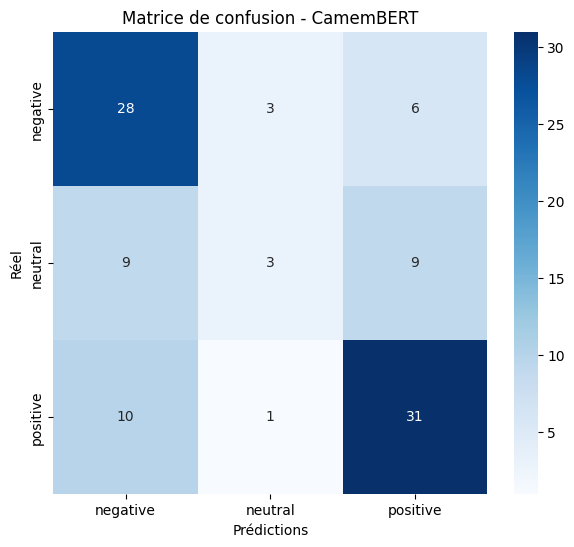

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm_camembert = confusion_matrix(

    y_true_camembert,

    y_pred_camembert
)
plt.figure(figsize=(7,6))

sns.heatmap(

    cm_camembert,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=label_encoder.classes_,

    yticklabels=label_encoder.classes_
)

plt.xlabel("Prédictions")

plt.ylabel("Réel")

plt.title(
    "Matrice de confusion - CamemBERT"
)

plt.show()

La classe neutral est la plus difficile à prédire pour l’ensemble des modèles testés. Malgré l’utilisation de modèles avancés comme  CamemBERT, les performances sur cette classe restent faibles en raison de son ambiguïté sémantique et du nombre plus limité d’exemples disponibles dans le dataset.